# Notebook 2: Teacher Model (Thick-File XGBoost)
Trains on users with full credit history. Outputs calibrated soft probabilities for knowledge distillation.

In [5]:
import pandas as pd
import numpy as np
import json, pickle, warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report

# ── Load data & feature sets ───────────────────────────────────────────────
thick = pd.read_parquet('thick_file_dataset.parquet')
with open('feature_sets.json') as f:
    fs = json.load(f)

TEACHER_FEATURES = fs['teacher']

# Teacher trains ONLY on thick-file users (those with at least some history)
train_df = thick[thick['IS_THIN_FILE'] == 0].reset_index(drop=True)
print(f'Teacher training set: {train_df.shape} | default rate: {train_df["TARGET"].mean():.3f}')

Teacher training set: (305271, 57) | default rate: 0.081


## 1. Train/Validation Split (Stratified)

In [6]:
from sklearn.model_selection import train_test_split

X = train_df[TEACHER_FEATURES]
y = train_df['TARGET']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {X_train.shape} | Val: {X_val.shape}')

Train: (244216, 54) | Val: (61055, 54)


## 2. XGBoost Teacher Model
- `scale_pos_weight` handles class imbalance without oversampling
- `eval_metric=auc` with early stopping prevents overfit

In [7]:
# Three-way split: train → fit XGB, cal → fit isotonic, val → evaluate
# Why: cv='prefit' requires the base model to already be fitted.
# Calibration must fit on HELD-OUT data to avoid overfitting the calibrator.
# If you calibrate on val and evaluate on val you get optimistic calibration metrics —
# use a separate cal set for fitting and val set only for final evaluation.
X_train2, X_cal, y_train2, y_cal = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=0
)

neg, pos = (y_train2 == 0).sum(), (y_train2 == 1).sum()
spw = neg / pos

# early_stopping_rounds lives on the model — XGB needs eval_set in .fit()
# CalibratedClassifierCV(cv='prefit') calls NO internal fit, so early stopping
# is irrelevant there. Keep it only on the base XGB .fit() call.
xgb_teacher = XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = spw,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    eval_metric           = 'auc',
    early_stopping_rounds = 30,
    random_state          = 42,
    tree_method           = 'hist',
    verbosity             = 0,
)

xgb_teacher.fit(
    X_train2, y_train2,
    eval_set=[(X_cal, y_cal)],   # early stopping monitors this
    verbose=100
)

val_preds = xgb_teacher.predict_proba(X_val)[:, 1]
print(f'\nTeacher Val ROC-AUC : {roc_auc_score(y_val, val_preds):.4f}')
print(f'Teacher Val PR-AUC  : {average_precision_score(y_val, val_preds):.4f}')

[0]	validation_0-auc:0.64506
[100]	validation_0-auc:0.71994
[200]	validation_0-auc:0.72500
[300]	validation_0-auc:0.72608
[306]	validation_0-auc:0.72617

Teacher Val ROC-AUC : 0.7331
Teacher Val PR-AUC  : 0.2163


## 3. Probability Calibration
Raw XGBoost probabilities are often poorly calibrated. Isotonic calibration fixes systematic over/under-confidence.

In [8]:
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Get raw teacher probabilities on calibration set
raw_cal_probs = xgb_teacher.predict_proba(X_cal)[:, 1]

# 2. Fit isotonic calibrator (NO re-training of XGBoost)
iso_calibrator = IsotonicRegression(out_of_bounds='clip')
iso_calibrator.fit(raw_cal_probs, y_cal)

# 3. Evaluate on validation set
raw_val_probs = xgb_teacher.predict_proba(X_val)[:, 1]
cal_preds = iso_calibrator.transform(raw_val_probs)

print(f'Calibrated Val ROC-AUC : {roc_auc_score(y_val, cal_preds):.4f}')
print(f'Mean predicted prob    : {cal_preds.mean():.4f}')
print(f'Actual default rate    : {y_val.mean():.4f}')

Calibrated Val ROC-AUC : 0.7325
Mean predicted prob    : 0.0810
Actual default rate    : 0.0808


## 4. Generate Soft Labels for ALL Users
This is the core of knowledge distillation. The teacher scores every user (including thin-file). These soft probabilities become the student's training target — richer than binary 0/1 labels.

In [9]:
# Score the ENTIRE thick dataset (thick + thin file users)
# For thin-file users: history cols are 0 (imputed), teacher still produces a score
# This score = what a full-data model WOULD predict given similar demographics

all_X = thick[TEACHER_FEATURES]
# Get raw probs from teacher
raw_all_probs = xgb_teacher.predict_proba(all_X)[:, 1]

# Pass through calibrator
thick['SOFT_LABEL'] = iso_calibrator.transform(raw_all_probs)

print('Soft label distribution:')
print(thick['SOFT_LABEL'].describe().round(4))
print()
print('Thin-file soft labels vs thick-file soft labels:')
print(thick.groupby('IS_THIN_FILE')['SOFT_LABEL'].describe().round(4))

Soft label distribution:
count    307511.0000
mean          0.0812
std           0.0707
min           0.0000
25%           0.0353
50%           0.0640
75%           0.1006
max           1.0000
Name: SOFT_LABEL, dtype: float64

Thin-file soft labels vs thick-file soft labels:
                 count    mean     std  min     25%    50%     75%     max
IS_THIN_FILE                                                              
0             305271.0  0.0813  0.0708  0.0  0.0353  0.064  0.1006  1.0000
1               2240.0  0.0787  0.0538  0.0  0.0353  0.064  0.1006  0.3401


## 5. Feature Importance (Teacher)

Top 20 Teacher Features:
NAME_EDUCATION_TYPE      0.0638
cc_avg_utilization       0.0436
REGION_RATING_CLIENT     0.0414
NAME_INCOME_TYPE         0.0348
prev_refused_count       0.0348
inst_late_rate           0.0337
CREDIT_TO_GOODS          0.0305
bureau_active_count      0.0285
bureau_closed_count      0.0272
AGE_YEARS                0.0268
EMPLOYED_YEARS           0.0261
prev_approval_rate       0.0219
FLAG_OWN_CAR             0.0217
AMT_GOODS_PRICE          0.0214
prev_approved_count      0.0194
cc_avg_drawings          0.0193
cc_max_utilization       0.0191
bureau_total_debt        0.0188
cc_months_active         0.0184
prev_avg_down_payment    0.0175


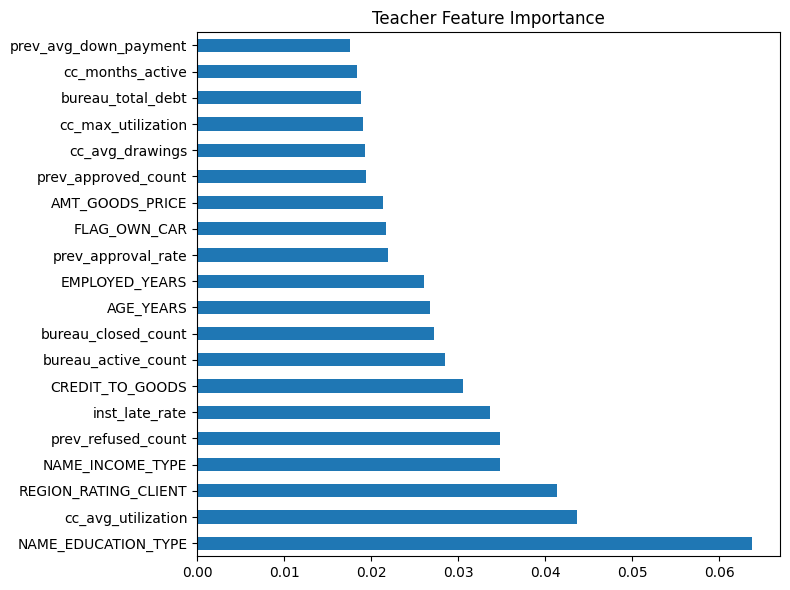

In [10]:
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    xgb_teacher.feature_importances_,
    index=TEACHER_FEATURES
).sort_values(ascending=False)

print('Top 20 Teacher Features:')
print(feat_imp.head(20).round(4).to_string())

feat_imp.head(20).plot(kind='barh', figsize=(8, 6), title='Teacher Feature Importance')
plt.tight_layout()
plt.savefig('teacher_feature_importance.png', dpi=120)
plt.show()

## 6. Save Teacher + Labeled Dataset

In [12]:
import pickle

# Save BOTH teacher model + calibrator together
with open('teacher_model.pkl', 'wb') as f:
    pickle.dump({
        "model": xgb_teacher,
        "calibrator": iso_calibrator
    }, f)

# Save dataset with soft labels
thick.to_parquet('thick_with_soft_labels.parquet', index=False)

print('Saved: teacher_model.pkl (model + calibrator)')
print('Saved: thick_with_soft_labels.parquet')
print()
print('Ready for Notebook 3: Student Model Training')

Saved: teacher_model.pkl (model + calibrator)
Saved: thick_with_soft_labels.parquet

Ready for Notebook 3: Student Model Training
